In [132]:
import matplotlib.pyplot as plt
import json
from matplotlib import rcParams

In [133]:
# ====== 参数设置 ======
json_path = "/data/wenjing/skin_dataset/rose-outputs/training_metrics.json"
json_path_2 = "/data/wenjing/skin_dataset/rose-outputs-11/training_metrics.json"
# ====== 读取 JSON 文件 ======
data1 = []
data2 = []
with open(json_path, "r") as f:
    for line in f:
        data1.append(json.loads(line.strip()))

with open(json_path_2, "r") as f:
    for line in f:
        data2.append(json.loads(line.strip()))

iterations1 = [d["iteration"] for d in data1]
iterations2 = [d["iteration"] for d in data2]
dino_global_loss = [d["dino_local_crops_loss"] for d in data1]
rose_global_loss = [d["dino_local_crops_loss"] for i, d in enumerate(data2)]

In [134]:
# 字体与样式
rcParams['font.family'] = 'Times New Roman'   # 全局字体
rcParams['axes.labelsize'] = 13
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['axes.titlesize'] = 13  # 控制所有标题字体大小

# 坐标轴标题与坐标轴的距离
x_labelpad = 4   # 横坐标标题距离
y_labelpad = 4  # 纵坐标标题距离

# 曲线样式
line_color = "#2878B5"
line_width = 1.2

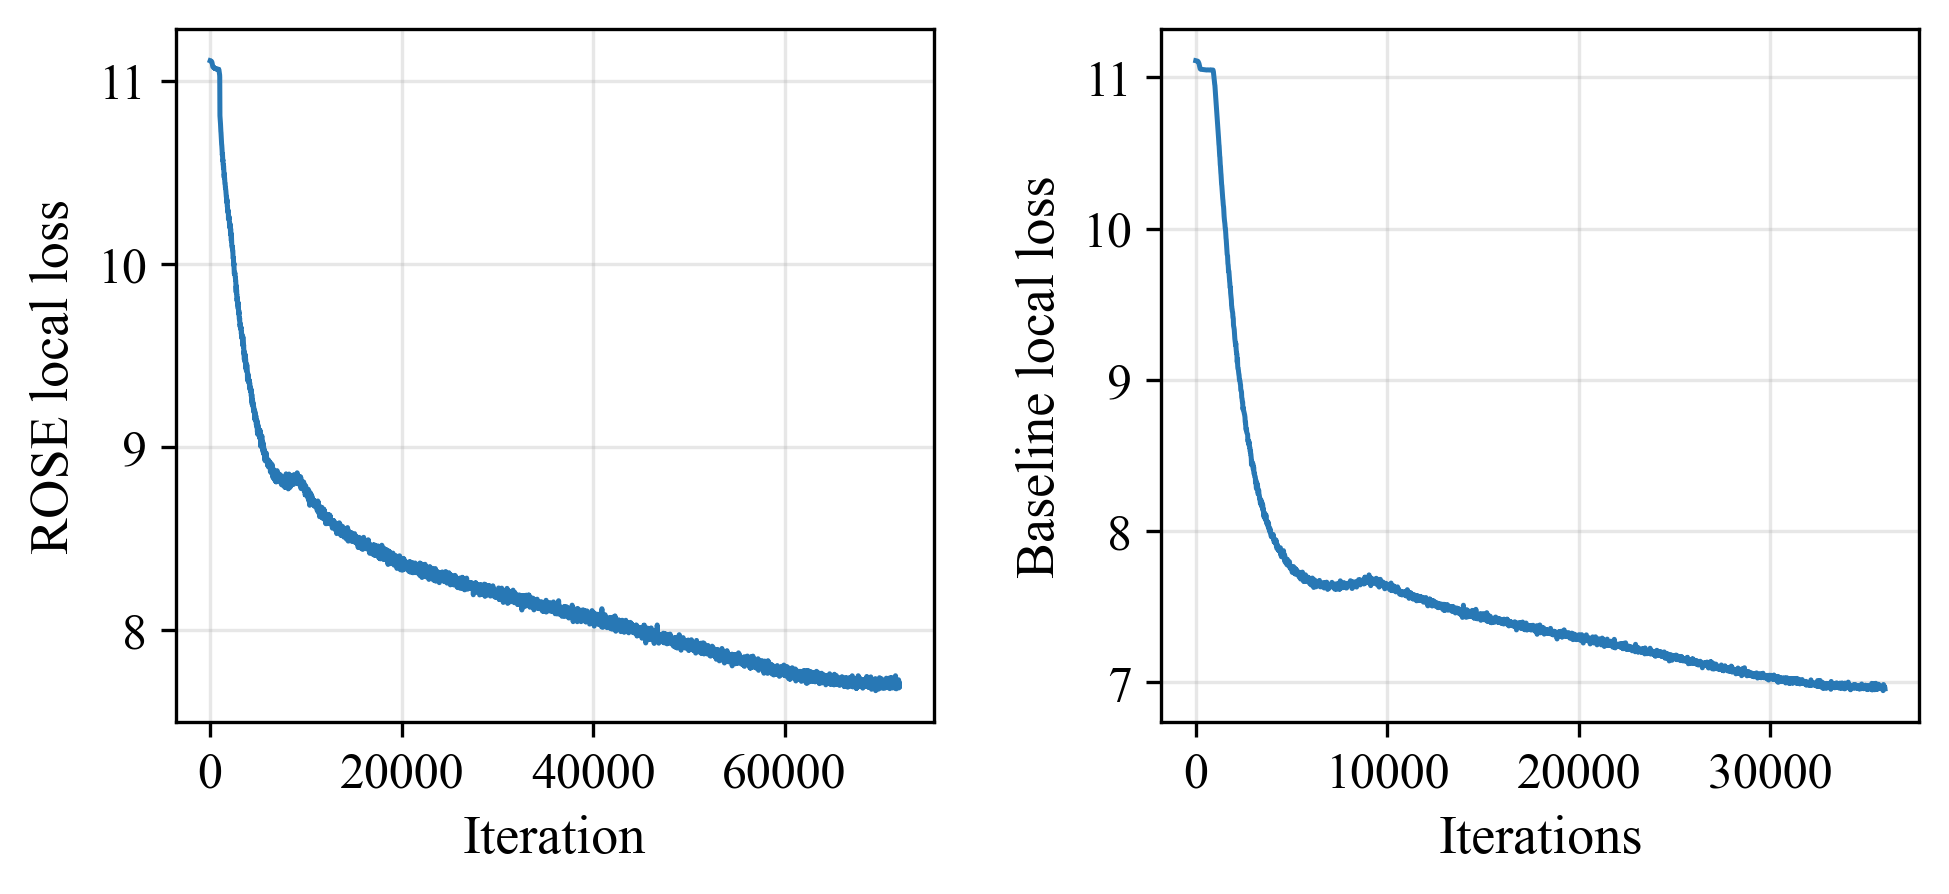

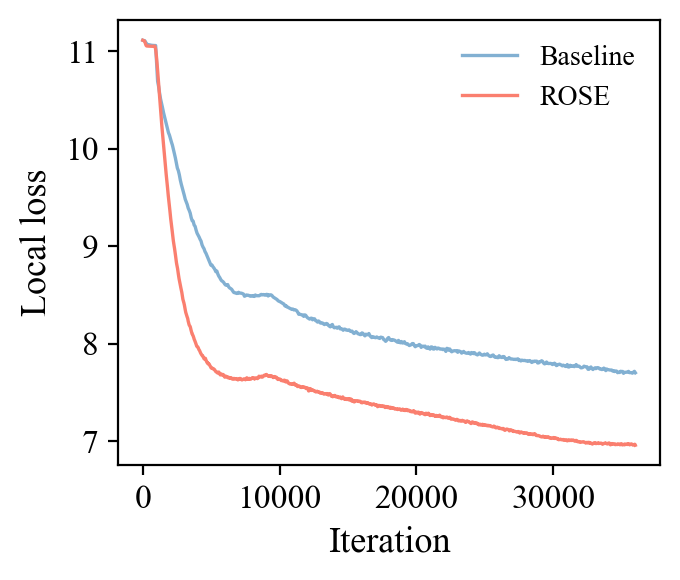

In [135]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
# ====== 绘制两个子图 ======
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3), dpi=300)
plt.subplots_adjust(wspace=0.3)  # 控制子图间距
for i in range(len(rose_global_loss)):
    if i > 100:
        rose_global_loss[i] = rose_global_loss[i] - 0.2  # 截断过高的loss值，便于可视化
# --- 子图1: DINO Global Loss ---
axes[0].plot(iterations2, rose_global_loss, color=line_color, linewidth=line_width)
axes[0].set_xlabel("Iteration", labelpad=x_labelpad)
axes[0].set_ylabel("ROSE local loss", labelpad=y_labelpad)
axes[0].grid(True, linestyle='-', alpha=0.3)

# --- 子图2: iBOT Loss ---
axes[1].plot(iterations1, dino_global_loss, color=line_color, linewidth=line_width)
axes[1].set_xlabel("Iterations", labelpad=x_labelpad)
axes[1].set_ylabel("Baseline local loss", labelpad=y_labelpad)
axes[1].grid(True, linestyle='-', alpha=0.3)

# ====== 平滑曲线参数 ======
window_length = 21  # 必须是奇数，越大越平滑
polyorder = 3       # 多项式阶数
import numpy as np
# 平滑数据
dino_global_loss_smooth = savgol_filter(dino_global_loss, window_length, polyorder)
rose_global_loss_smooth = savgol_filter(rose_global_loss, window_length, polyorder)
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 假设原始数据
iterations2 = np.array(iterations2)
rose_global_loss_smooth = np.array(rose_global_loss_smooth)

# 1️⃣ 截取 iteration <= 35000
max_iter = 36000
mask = iterations2 <= max_iter
x_clip = iterations2[mask]
y_clip = rose_global_loss_smooth[mask]

# 2️⃣ 插值，保证起点和终点 min/max 不变
# 原曲线的 min 和 max
y_min, y_max = rose_global_loss_smooth.min(), rose_global_loss_smooth.max()

# 生成新的采样点（例如 500 个点）
x_new = np.linspace(x_clip.min(), x_clip.max(), 500)

# 插值函数
f_interp = interp1d(x_clip, y_clip, kind='linear')
y_new = f_interp(x_new)

# 3️⃣ 调整使 min/max 不变
scale = (y_max - y_min) / (y_new.max() - y_new.min())
y_new = (y_new - y_new.min()) * scale + y_min

# ====== 绘图 ======
fig = plt.figure(figsize=(3.5, 3), dpi=200)
plt.plot(x_new, y_new, color="#82B0D2", linewidth=line_width, label="Baseline")
plt.plot(iterations1, dino_global_loss_smooth, color="#FA7F6F", linewidth=line_width, label="ROSE")
plt.xlabel("Iteration", labelpad=x_labelpad)
plt.ylabel("Local loss", labelpad=y_labelpad)
plt.grid(True, linestyle='-', alpha=0.0)
plt.legend(frameon=False)
plt.tight_layout()
fig.savefig("article_figures/local_loss_comparison_clipped.pdf", format='pdf')



In [136]:
a = [1,2,3]
a = [x - 1 for x in a]
print(a)

[0, 1, 2]
